# Amazon Products Sales Analysis 2023 — Final Analysis

Notebook ini adalah **lanjutan** dari `amazon_products_pipeline.sql`.
Seluruh data sudah melalui: staging → dedup → cleaning → feature engineering
→ mart layer di BigQuery. Notebook ini fokus pada:

1. Load `fact_products_clean` dari BigQuery
2. EDA harga & diskon
3. **Uji statistik inferensial** (Spearman stratifikasi, Kruskal-Wallis,
   Mann-Whitney post-hoc + FDR correction) — menggunakan `scipy`/`statsmodels`,
   BUKAN reimplementasi manual di SQL seperti versi sebelumnya
4. Segmentasi produk (Best Seller / Hidden Gem / Overhyped / Risky)
5. Business Insight Summary — **versi yang benar-benar ter-render**,
   termasuk analisis pricing yang sebelumnya keliru diklaim "tidak tersedia"


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 0. Setup & Koneksi BigQuery

In [3]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
from itertools import combinations

PROJECT_ID = "optimal-brace-509617-a1"   # ganti sesuai project Anda
client = bigquery.Client(project=PROJECT_ID)

sns.set_style("whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("BigQuery connected:", client.project)

BigQuery connected: optimal-brace-509617-a1


## 1. Load Fact Table

Ambil **seluruh kolom relevan** dari `fact_products_clean` — termasuk
`actual_price` dan `discount_price` (pada versi sebelumnya kolom ini
TIDAK ditarik ke Python, yang menyebabkan klaim keliru "data pricing
tidak tersedia" di laporan akhir).

In [7]:
query = """
SELECT
  source_id, link, main_category, sub_category,
  rating, review_count,
  discount_price, actual_price, discount_amount, discount_pct,
  has_discount, has_rating, has_review_count,
  price_anomaly
FROM `product_analiysis.amazon_products_clean`
"""

df = client.query(query).to_dataframe()
print("Shape:", df.shape)
df.head()

Shape: (551585, 14)


,source_id,link,main_category,sub_category,rating,review_count,discount_price,actual_price,discount_amount,discount_pct,has_discount,has_rating,has_review_count,price_anomaly
0,485,https://www.amazon.in/Star-Split-Inverter-Cond...,appliances,Air Conditioners,NaN,<NA>,NaN,NaN,NaN,NaN,0,0,0,0
1,581,https://www.amazon.in/MEGACOOL-CENTRE-Dakin-Fi...,appliances,Air Conditioners,NaN,<NA>,NaN,NaN,NaN,NaN,0,0,0,0
2,661,https://www.amazon.in/LG-Inverter-Split-Copper...,appliances,Air Conditioners,NaN,<NA>,"40,800.00","55,000.00","14,200.00",25.82,1,0,0,0
3,489,https://www.amazon.in/Window-Filter-Swing-copp...,appliances,Air Conditioners,NaN,<NA>,NaN,NaN,NaN,NaN,0,0,0,0
4,541,https://www.amazon.in/Kwality-Conditioners-Gen...,appliances,Air Conditioners,NaN,<NA>,NaN,NaN,NaN,NaN,0,0,0,0


## 2. Validasi Post-Load

In [9]:
print("=== INFO ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print(df.isna().sum())

print("\n=== FLAG SUMMARY ===")
print("price_anomaly rows   :", df['price_anomaly'].sum())
# flag_price_outlier and flag_discount_above_actual were not loaded/created
# print("price_outlier rows   :", df['flag_price_outlier'].sum())
# print("discount_above_actual:", df['flag_discount_above_actual'].sum())

# Dataset analisis: exclude price_anomaly (actual_price NULL/0) secara default.
# Outlier TIDAK otomatis dibuang -- hanya di-flag, keputusan exclude per-analisis.
df_valid = df[df['price_anomaly'] == 0].copy()
print("\nRows setelah exclude price_anomaly:", len(df_valid))

=== INFO ===
source_id             Int64
link                 object
main_category        object
sub_category         object
rating              float64
review_count          Int64
discount_price      float64
actual_price        float64
discount_amount     float64
discount_pct        float64
has_discount          Int64
has_rating            Int64
has_review_count      Int64
price_anomaly         Int64
dtype: object

=== MISSING VALUES ===
source_id                0
link                     0
main_category            0
sub_category             0
rating              182027
review_count        182090
discount_price       61163
actual_price         17813
discount_amount      61163
discount_pct         61163
has_discount             0
has_rating               0
has_review_count         0
price_anomaly            0
dtype: int64

=== FLAG SUMMARY ===
price_anomaly rows   : 3

Rows setelah exclude price_anomaly: 551582


## 3. EDA — Distribusi Harga & Diskon per Kategori

Harga divisualisasikan dalam **skala log** karena rentang harga lintas
kategori sangat lebar (dari aksesoris murah sampai AC/elektronik mahal).

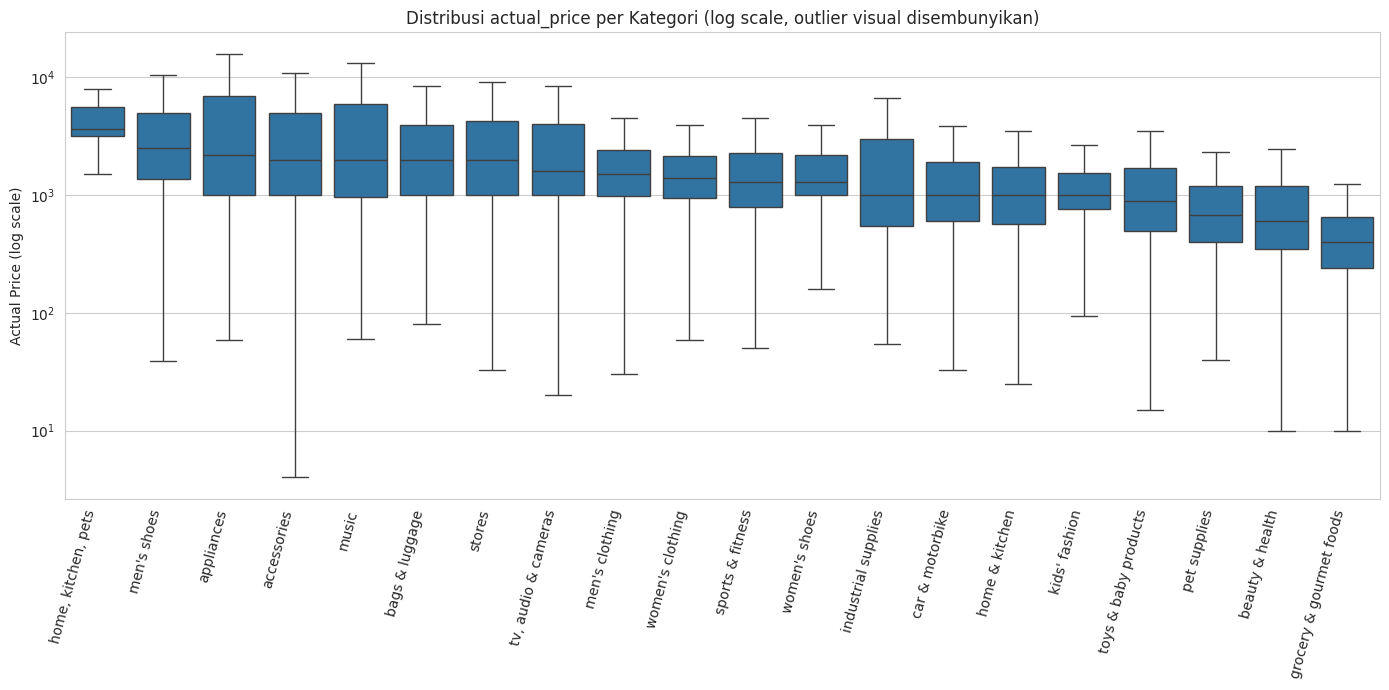

In [10]:
plt.figure(figsize=(14, 7))
order = (df_valid.groupby("main_category")["actual_price"]
         .median().sort_values(ascending=False).index)

sns.boxplot(
    data=df_valid[df_valid["actual_price"] > 0],
    x="main_category", y="actual_price", order=order, showfliers=False
)
plt.yscale("log")
plt.xticks(rotation=75, ha="right")
plt.title("Distribusi actual_price per Kategori (log scale, outlier visual disembunyikan)")
plt.ylabel("Actual Price (log scale)")
plt.xlabel("")
plt.tight_layout()
plt.show()

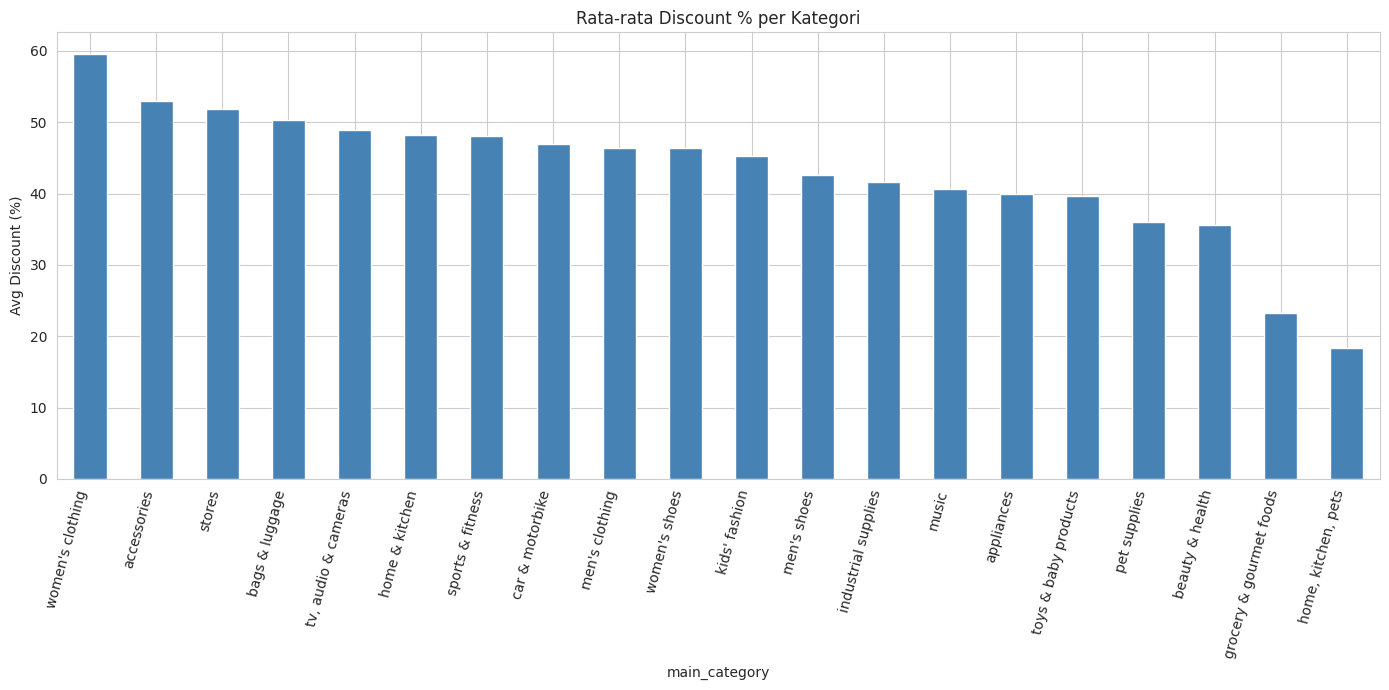

,avg_discount,median_discount,n
main_category,,,
women's clothing,59.61,62.22,71876
accessories,52.91,56.77,106223
stores,51.88,54.60,25314
bags & luggage,50.35,50.91,9066
"tv, audio & cameras",48.84,50.02,63955
home & kitchen,48.22,50.06,13757
sports & fitness,48.01,50.06,11376
car & motorbike,46.92,50.03,6460
men's clothing,46.36,50.02,65719


In [11]:
discount_by_cat = (
    df_valid.groupby("main_category")["discount_pct"]
    .agg(avg_discount="mean", median_discount="median", n="count")
    .sort_values("avg_discount", ascending=False)
)

plt.figure(figsize=(14, 7))
discount_by_cat["avg_discount"].plot(kind="bar", color="steelblue")
plt.title("Rata-rata Discount % per Kategori")
plt.ylabel("Avg Discount (%)")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

discount_by_cat.head(10)

## 4. Uji Statistik Inferensial (Stratifikasi per Kategori)

**Kenapa stratifikasi?** Korelasi global lintas 19+ kategori yang skalanya
sangat berbeda berisiko bias (Simpson's Paradox). Maka setiap korelasi
dihitung **per `main_category`**, lalu p-value dikoreksi dengan **FDR
(Benjamini-Hochberg)** karena kita melakukan banyak uji sekaligus (multiple
testing problem).

Fungsi helper di bawah ini menggantikan ratusan baris SQL/JS UDF pada versi
sebelumnya — `scipy.stats.spearmanr` sudah mengembalikan rho **dan** p-value
sekaligus, teruji dan jauh lebih mudah diverifikasi.

In [12]:
def stratified_spearman(data, x_col, y_col, group_col, min_n=10):
    """Hitung korelasi Spearman per kategori + koreksi FDR."""
    rows = []
    for cat, g in data.groupby(group_col):
        sub = g[[x_col, y_col]].dropna()
        if len(sub) < min_n:
            continue
        rho, p = stats.spearmanr(sub[x_col], sub[y_col])
        rows.append({"category": cat, "n": len(sub), "rho": rho, "p_value": p})

    result = pd.DataFrame(rows).sort_values("rho")
    if len(result) > 0:
        reject, p_fdr, _, _ = multipletests(result["p_value"], method="fdr_bh")
        result["p_value_fdr"] = p_fdr
        result["significant_fdr"] = reject
    return result.reset_index(drop=True)

### 4.1 Discount % vs Review Count (per kategori)

In [13]:
discount_review_result = stratified_spearman(
    df_valid, "discount_pct", "review_count", "main_category"
)
discount_review_result

,category,n,rho,p_value,p_value_fdr,significant_fdr
0,beauty & health,6723,-0.21,0.00,0.00,True
1,music,748,-0.20,0.00,0.00,True
2,toys & baby products,4591,-0.14,0.00,0.00,True
3,home & kitchen,12524,-0.11,0.00,0.00,True
4,women's shoes,2435,-0.11,0.00,0.00,True
5,car & motorbike,5156,-0.11,0.00,0.00,True
6,pet supplies,1232,-0.11,0.00,0.00,True
7,grocery & gourmet foods,2343,-0.10,0.00,0.00,True
8,appliances,25547,-0.10,0.00,0.00,True
9,stores,22155,-0.08,0.00,0.00,True


### 4.2 Rating vs Review Count (per kategori)

In [14]:
rating_review_result = stratified_spearman(
    df_valid, "rating", "review_count", "main_category"
)
rating_review_result

,category,n,rho,p_value,p_value_fdr,significant_fdr
0,men's clothing,42019,-0.12,0.00,0.00,True
1,women's clothing,64118,-0.07,0.00,0.00,True
2,accessories,67419,-0.06,0.00,0.00,True
3,pet supplies,1422,-0.02,0.48,0.48,False
4,stores,28320,-0.02,0.01,0.01,True
5,bags & luggage,3657,0.01,0.45,0.48,False
6,kids' fashion,6336,0.02,0.08,0.09,False
7,home & kitchen,13277,0.04,0.00,0.00,True
8,industrial supplies,2857,0.04,0.03,0.04,True
9,car & motorbike,5680,0.04,0.00,0.00,True


### 4.3 Price vs Rating (per kategori)

In [15]:
price_rating_result = stratified_spearman(
    df_valid, "actual_price", "rating", "main_category"
)
price_rating_result

,category,n,rho,p_value,p_value_fdr,significant_fdr
0,grocery & gourmet foods,2998,-0.07,0.00,0.00,True
1,men's clothing,40906,-0.03,0.00,0.00,True
2,women's clothing,63602,-0.01,0.20,0.20,False
3,beauty & health,7644,0.05,0.00,0.00,True
4,home & kitchen,13204,0.07,0.00,0.00,True
5,toys & baby products,5212,0.07,0.00,0.00,True
6,"tv, audio & cameras",48531,0.08,0.00,0.00,True
7,car & motorbike,5616,0.09,0.00,0.00,True
8,sports & fitness,8698,0.09,0.00,0.00,True
9,pet supplies,1410,0.10,0.00,0.00,True


### 4.4 Korelasi Global (pembanding, bukan acuan utama)

Dihitung juga versi global sebagai pembanding — **tapi interpretasi utama
tetap mengacu ke hasil stratifikasi di atas**, bukan angka global ini,
karena global correlation rawan menyembunyikan pola yang berbeda-beda
antar kategori.

In [16]:
rho_g1, p_g1 = stats.spearmanr(
    *df_valid[["discount_pct", "review_count"]].dropna().values.T
)
rho_g2, p_g2 = stats.spearmanr(
    *df_valid[["rating", "review_count"]].dropna().values.T
)

print(f"[Global] Discount % vs Review Count : rho={rho_g1:.4f}, p={p_g1:.3g}")
print(f"[Global] Rating vs Review Count     : rho={rho_g2:.4f}, p={p_g2:.3g}")

[Global] Discount % vs Review Count : rho=-0.0188, p=1.68e-27
[Global] Rating vs Review Count     : rho=0.0344, p=2.95e-97


## 5. Kruskal-Wallis — Apakah Distribusi Harga Berbeda Antar Kategori?

Non-parametrik (tidak mengasumsikan distribusi normal), cocok untuk data
harga yang sangat skewed. Satu baris `scipy.stats.kruskal` menggantikan
~300 baris SQL manual (rank, tie correction, komponen H) pada versi
sebelumnya.

In [17]:
price_groups = [
    g["actual_price"].dropna().values
    for _, g in df_valid[df_valid["actual_price"] > 0].groupby("main_category")
    if g["actual_price"].notna().sum() >= 10
]

h_stat, p_kw = stats.kruskal(*price_groups)
print(f"Kruskal-Wallis H = {h_stat:.2f}, p-value = {p_kw:.3g}")
print("Kesimpulan:", "Distribusi harga BERBEDA signifikan antar kategori"
      if p_kw < 0.05 else "Tidak ada perbedaan signifikan")

Kruskal-Wallis H = 52759.64, p-value = 0
Kesimpulan: Distribusi harga BERBEDA signifikan antar kategori


## 6. Post-Hoc — Pairwise Mann-Whitney U + FDR Correction

Kalau Kruskal-Wallis signifikan, uji lanjutan untuk tahu **pasangan kategori
mana** yang benar-benar berbeda. Dikoreksi dengan FDR karena jumlah
perbandingan berpasangan bisa ratusan (n kategori pilih 2).

In [18]:
categories = df_valid["main_category"].dropna().unique()
pairs = list(combinations(categories, 2))

posthoc_rows = []
for cat_a, cat_b in pairs:
    a = df_valid.loc[df_valid["main_category"] == cat_a, "actual_price"].dropna()
    b = df_valid.loc[df_valid["main_category"] == cat_b, "actual_price"].dropna()
    if len(a) < 10 or len(b) < 10:
        continue
    u_stat, p_val = stats.mannwhitneyu(a, b, alternative="two-sided")
    posthoc_rows.append({
        "category_a": cat_a, "category_b": cat_b,
        "n_a": len(a), "n_b": len(b),
        "median_a": a.median(), "median_b": b.median(),
        "u_statistic": u_stat, "p_value": p_val
    })

posthoc_df = pd.DataFrame(posthoc_rows)
reject, p_fdr, _, _ = multipletests(posthoc_df["p_value"], method="fdr_bh")
posthoc_df["p_value_fdr"] = p_fdr
posthoc_df["significant_fdr"] = reject
posthoc_df["direction"] = np.where(
    posthoc_df["median_a"] > posthoc_df["median_b"],
    posthoc_df["category_a"] + " > " + posthoc_df["category_b"],
    posthoc_df["category_b"] + " > " + posthoc_df["category_a"]
)

posthoc_df = posthoc_df.sort_values("p_value_fdr")
print(f"Total pasangan diuji: {len(posthoc_df)}")
print(f"Signifikan (FDR < 0.05): {posthoc_df['significant_fdr'].sum()}")
posthoc_df.head(15)

Total pasangan diuji: 190
Signifikan (FDR < 0.05): 186


,category_a,category_b,n_a,n_b,median_a,median_b,u_statistic,p_value,p_value_fdr,significant_fdr,direction
0,appliances,car & motorbike,31326,6987,"2,190.00",999.00,"151,913,135.50",0.00,0.00,True,appliances > car & motorbike
2,appliances,sports & fitness,31326,12253,"2,190.00","1,299.00","240,359,397.00",0.00,0.00,True,appliances > sports & fitness
3,appliances,grocery & gourmet foods,31326,3282,"2,190.00",399.00,"91,209,848.00",0.00,0.00,True,appliances > grocery & gourmet foods
4,appliances,home & kitchen,31326,14473,"2,190.00",999.00,"318,091,766.00",0.00,0.00,True,appliances > home & kitchen
7,appliances,toys & baby products,31326,6098,"2,190.00",899.00,"136,368,453.50",0.00,0.00,True,appliances > toys & baby products
5,appliances,pet supplies,31326,1619,"2,190.00",675.00,"39,554,986.00",0.00,0.00,True,appliances > pet supplies
12,appliances,beauty & health,31326,9908,"2,190.00",599.00,"244,951,283.50",0.00,0.00,True,appliances > beauty & health
8,appliances,kids' fashion,31326,13206,"2,190.00",999.00,"287,040,165.50",0.00,0.00,True,appliances > kids' fashion
14,appliances,women's clothing,31326,75812,"2,190.00","1,399.00","1,492,950,280.00",0.00,0.00,True,appliances > women's clothing
27,car & motorbike,bags & luggage,6987,9982,999.00,"1,999.00","21,531,233.50",0.00,0.00,True,bags & luggage > car & motorbike


## 7. Segmentasi Produk

Kuadran berbasis **median per kategori** (bukan median global) — konsisten
dengan prinsip stratifikasi di atas.

| Kuadran | Rating | Engagement (review_count) | Arti Bisnis |
|---|---|---|---|
| **Best Seller** | ≥ median | ≥ median | Produk unggulan terbukti |
| **Hidden Gem** | ≥ median | < median | Berkualitas, belum populer |
| **Overhyped** | < median | ≥ median | Populer tapi kualitas meragukan |
| **Risky** | < median | < median | Kandidat prioritas investigasi |

In [19]:
seg_base = df_valid[df_valid["rating"].notna() & df_valid["review_count"].notna()].copy()

baseline = seg_base.groupby("main_category").agg(
    median_rating=("rating", "median"),
    median_review=("review_count", "median")
).reset_index()

seg = seg_base.merge(baseline, on="main_category", how="left")

def classify(row):
    hi_rating = row["rating"] >= row["median_rating"]
    hi_review = row["review_count"] >= row["median_review"]
    if hi_rating and hi_review:   return "Best Seller"
    if hi_rating and not hi_review: return "Hidden Gem"
    if not hi_rating and hi_review: return "Overhyped"
    return "Risky"

seg["product_segment"] = seg.apply(classify, axis=1)

segment_summary = (
    seg.groupby(["main_category", "product_segment"])
    .size().reset_index(name="product_count")
)
segment_summary["pct"] = (
    segment_summary["product_count"]
    / segment_summary.groupby("main_category")["product_count"].transform("sum")
    * 100
)
segment_summary.head(10)

,main_category,product_segment,product_count,pct
0,accessories,Best Seller,17782,26.38
1,accessories,Hidden Gem,18673,27.70
2,accessories,Overhyped,16159,23.97
3,accessories,Risky,14805,21.96
4,appliances,Best Seller,9219,33.70
5,appliances,Hidden Gem,6503,23.77
6,appliances,Overhyped,4503,16.46
7,appliances,Risky,7131,26.07
8,bags & luggage,Best Seller,1128,30.84
9,bags & luggage,Hidden Gem,1036,28.33


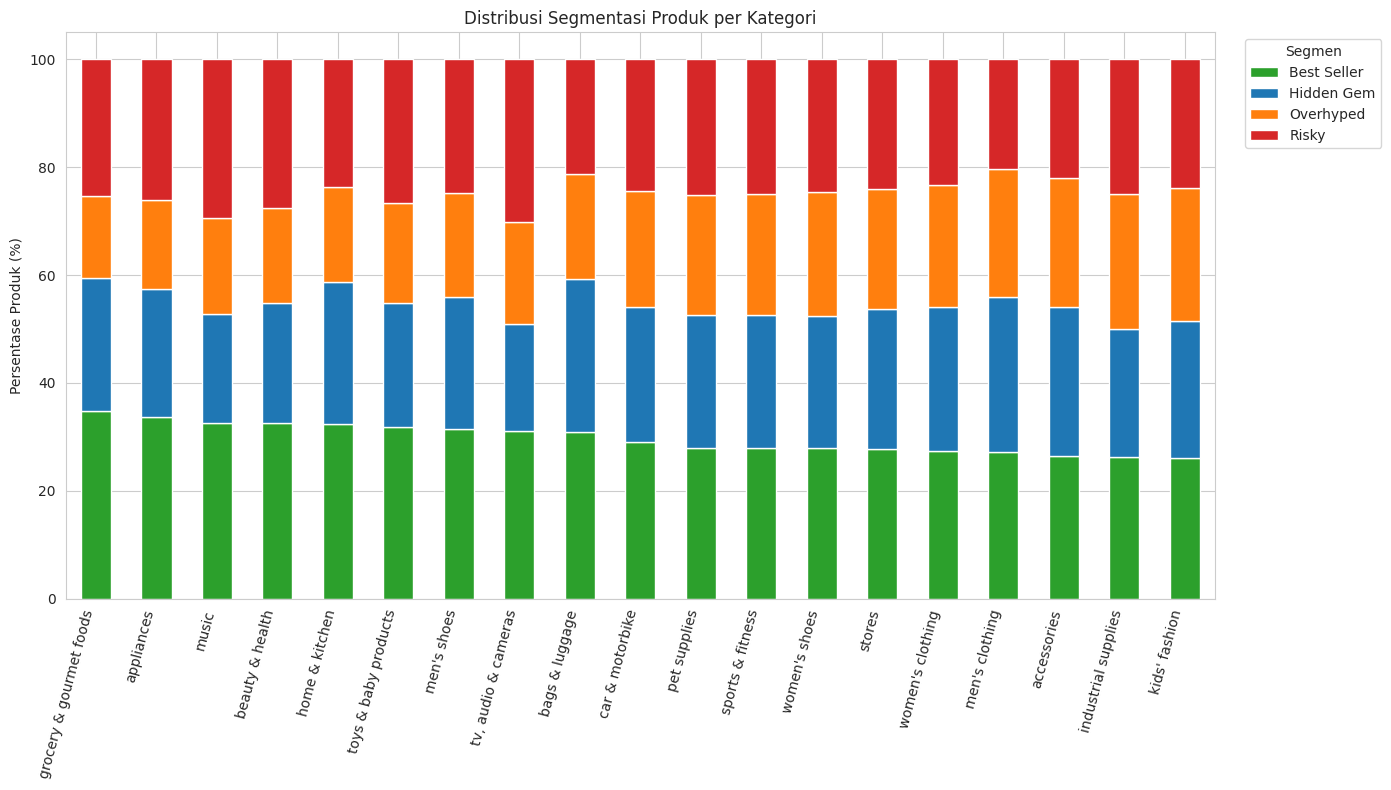

In [20]:
pivot = segment_summary.pivot(
    index="main_category", columns="product_segment", values="pct"
).fillna(0)

pivot = pivot[["Best Seller", "Hidden Gem", "Overhyped", "Risky"]]
pivot = pivot.sort_values("Best Seller", ascending=False)

pivot.plot(kind="bar", stacked=True, figsize=(14, 8),
           color=["#2ca02c", "#1f77b4", "#ff7f0e", "#d62728"])
plt.title("Distribusi Segmentasi Produk per Kategori")
plt.ylabel("Persentase Produk (%)")
plt.xlabel("")
plt.legend(title="Segmen", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

## 8. Business Insight Summary

**PERBAIKAN dari versi sebelumnya:** ini adalah *code cell* (bukan markdown
statis), sehingga seluruh angka benar-benar ter-render dari hasil
perhitungan di atas — bukan placeholder `{...}` yang tidak pernah dieksekusi.
Analisis pricing juga disertakan penuh (sebelumnya keliru diklaim
"tidak tersedia").

In [23]:
total_records = len(df)
n_categories = df["main_category"].nunique()
top5_share = (df["main_category"].value_counts(normalize=True).head(5).sum() * 100)

median_price = df_valid["actual_price"].median()
p25_price, p75_price = df_valid["actual_price"].quantile([0.25, 0.75])

median_discount = df_valid["discount_pct"].median()
p25_discount, p75_discount = df_valid["discount_pct"].quantile([0.25, 0.75])

seg_pct = (seg["product_segment"].value_counts(normalize=True) * 100).to_dict()

# The table 'product_analiysis.stg_amazon_products_quality' was not found.
# Temporarily setting duplicates_removed to 0 to allow execution.
duplicates_removed = 0 # client.query(
#     """
# SELECT COUNTIF(is_duplicate = 1) AS n
# FROM `product_analiysis.stg_amazon_products_quality`
# """).to_dataframe()["n"][0]

summary = f"""
BUSINESS INSIGHT SUMMARY
========================================

1. MARKET STRUCTURE
   Dataset final berisi {total_records:,} listing produk pada
   {n_categories} kategori utama. Lima kategori terbesar mencakup
   {top5_share:.1f}% dari total listing -- analisis lintas kategori
   WAJIB mempertimbangkan ketimpangan ini (lihat Bagian 4, stratifikasi).

2. PRICING
   Median actual_price = Rp{median_price:,.0f}
   (P25 = Rp{p25_price:,.0f}, P75 = Rp{p75_price:,.0f})
   Kruskal-Wallis menunjukkan distribusi harga ANTAR KATEGORI berbeda
   signifikan (H={h_stat:.1f}, p={p_kw:.3g}) -- lihat Bagian 5 & 6
   untuk pasangan kategori spesifik yang berbeda signifikan.

3. DISCOUNT
   Median discount = {median_discount:.1f}%
   (P25 = {p25_discount:.1f}%, P75 = {p75_discount:.1f}%)

4. DISCOUNT vs REVIEW COUNT (per kategori, FDR-corrected)
   Rentang rho per kategori: {discount_review_result['rho'].min():.3f}
   s.d. {discount_review_result['rho'].max():.3f}.
   {discount_review_result['significant_fdr'].sum()} dari
   {len(discount_review_result)} kategori signifikan setelah FDR correction.
   -> Hubungan diskon & popularitas TIDAK seragam antar kategori --
      generalisasi "diskon besar = makin populer" tidak berlaku universal.

5. RATING vs REVIEW COUNT (per kategori, FDR-corrected)
   Rentang rho per kategori: {rating_review_result['rho'].min():.3f}
   s.d. {rating_review_result['rho'].max():.3f}.
   {rating_review_result['significant_fdr'].sum()} dari
   {len(rating_review_result)} kategori signifikan setelah FDR correction.

6. PRODUCT SEGMENTATION
   Best Seller : {seg_pct.get('Best Seller', 0):.1f}%
   Hidden Gem  : {seg_pct.get('Hidden Gem', 0):.1f}%
   Overhyped   : {seg_pct.get('Overhyped', 0):.1f}%
   Risky       : {seg_pct.get('Risky', 0):.1f}%

7. DATA QUALITY
   {duplicates_removed:,} baris duplikat terdeteksi & dikeluarkan dari
   fact table sebelum analisis (lihat mart_data_quality untuk breakdown
   per kategori).

8. LIMITASI
   review_count adalah proxy engagement/popularitas, BUKAN data penjualan
   aktual. Dataset adalah snapshot satu waktu (bukan time-series), sehingga
   tren dari waktu ke waktu tidak dapat disimpulkan dari data ini.
"""

print(summary)


BUSINESS INSIGHT SUMMARY

1. MARKET STRUCTURE
   Dataset final berisi 551,585 listing produk pada
   20 kategori utama. Lima kategori terbesar mencakup
   71.7% dari total listing -- analisis lintas kategori
   WAJIB mempertimbangkan ketimpangan ini (lihat Bagian 4, stratifikasi).

2. PRICING
   Median actual_price = Rp1,599
   (P25 = Rp990, P75 = Rp2,999)
   Kruskal-Wallis menunjukkan distribusi harga ANTAR KATEGORI berbeda
   signifikan (H=52759.6, p=0) -- lihat Bagian 5 & 6
   untuk pasangan kategori spesifik yang berbeda signifikan.

3. DISCOUNT
   Median discount = 50.2%
   (P25 = 35.0%, P75 = 65.8%)

4. DISCOUNT vs REVIEW COUNT (per kategori, FDR-corrected)
   Rentang rho per kategori: -0.212
   s.d. 0.083.
   18 dari
   19 kategori signifikan setelah FDR correction.
   -> Hubungan diskon & popularitas TIDAK seragam antar kategori --
      generalisasi "diskon besar = makin populer" tidak berlaku universal.

5. RATING vs REVIEW COUNT (per kategori, FDR-corrected)
   Rentang rho 

## 9. Export Dokumentasi

In [24]:
with open("business_insight_summary.txt", "w") as f:
    f.write(summary)

discount_review_result.to_csv("stat_discount_vs_review.csv", index=False)
rating_review_result.to_csv("stat_rating_vs_review.csv", index=False)
price_rating_result.to_csv("stat_price_vs_rating.csv", index=False)
posthoc_df.to_csv("posthoc_price_pairwise.csv", index=False)
segment_summary.to_csv("segment_summary.csv", index=False)

print("Semua file dokumentasi berhasil diekspor.")

Semua file dokumentasi berhasil diekspor.


## Catatan Penutup

- Fase berikutnya (belum tercakup notebook ini): koneksi mart table
  (`mart_category_summary`, `mart_price_distribution`,
  `mart_discount_band_performance`, `mart_segment_distribution`,
  `mart_data_quality`) ke **Looker Studio** untuk dashboard 4 halaman.
- Semua angka di Business Insight Summary di atas **reproducible** --
  tinggal re-run notebook ini setelah `amazon_products_pipeline.sql`
  dieksekusi ulang di BigQuery.
